In [34]:
import pandas as pd

from google.colab import files
uploaded = files.upload()

Saving Phonepe-data_analysis.xlsx to Phonepe-data_analysis (2).xlsx


In [35]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
user = pd.read_excel("/content/Phonepe-data_analysis.xlsx")

# First 5 rows
user.head()


,User_ID,Name,Age,Join_Date,Unnamed: 4,0
0,PP0000001,Holly Rivera,56,2025-06-17,NaN,NaN
1,PP0000002,Kevin Lopez,46,2023-12-10,NaN,NaN
2,PP0000003,Douglas Roberts,32,2024-09-14,NaN,NaN
3,PP0000004,Walter Davila,60,2023-10-19,NaN,NaN
4,PP0000005,Grace Blake,25,2025-03-10,NaN,NaN


In [36]:
transactions = pd.read_excel(
    "/content/Phonepe-data_analysis.xlsx",
    sheet_name="All_Transactions"
)

transactions.head()

,Transaction_ID,Amount,User_ID,Service,Service Type,Payment_Status,Reason,Date
0,RCG_0C338474B366,926.59,PP0021371,Recharge_Bills,FASTag Recharge,Successful,Successful,2024-06-09
1,RCG_6B3B86B07A76,1211.64,PP0002388,Recharge_Bills,DTH,Successful,Successful,2024-08-04
2,RCG_767822392A0E,746.27,PP1101831,Recharge_Bills,Cable TV,Successful,Successful,2024-02-19
3,RCG_527E6AC74B11,1319.89,PP0033099,Recharge_Bills,Mobile Recharge,Successful,Successful,2024-12-22
4,RCG_6B50A8C694E1,112.44,PP1059869,Recharge_Bills,Cable TV,Successful,Successful,2024-09-07


In [37]:
# Dataset shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Column names
print(df.columns.tolist())

Rows: 300000
Columns: 14
['Transaction_ID', 'Amount', 'User_ID', 'Service', 'Service Type', 'Payment_Status', 'Reason', 'Date', 'Name', 'Age', 'Join_Date', 'Unnamed: 4', 0, 'Age_Group']


In [38]:
# Numerical summary
df.describe()




,Amount,Date,Age,Join_Date,Unnamed: 4,0
count,300000.000000,300000,300000.000000,300000,0.0,0.0
mean,11581.073114,2024-07-01 00:46:23.520000,39.065843,2024-08-01 03:24:31.679999488,NaN,NaN
min,20.000000,2024-01-01 00:00:00,18.000000,2023-08-03 00:00:00,NaN,NaN
25%,1345.587500,2024-04-01 00:00:00,28.000000,2024-02-01 00:00:00,NaN,NaN
50%,3091.450000,2024-07-01 00:00:00,39.000000,2024-07-31 00:00:00,NaN,NaN
75%,8769.805000,2024-10-01 00:00:00,50.000000,2025-01-30 00:00:00,NaN,NaN
max,99999.010000,2024-12-30 00:00:00,60.000000,2025-08-02 00:00:00,NaN,NaN
std,21376.115812,NaN,12.397426,NaN,NaN,NaN


In [39]:
# Missing values
df.isnull().sum()



,0
Transaction_ID,0
Amount,0
User_ID,0
Service,0
Service Type,0
Payment_Status,0
Reason,0
Date,0
Name,0
Age,0


In [40]:

# Duplicate rows
df.duplicated().sum()

np.int64(0)

In [41]:
## Payment Status Analysis
status_analysis = transactions.groupby("Payment_Status").agg(
    Transactions=("Transaction_ID", "count"),
    Total_Value=("Amount", "sum")
).sort_values("Transactions", ascending=False)

status_analysis


,Transactions,Total_Value
Payment_Status,,
Successful,287993,3.333026e+09
Failed,9980,3.931760e+07
Wrong PIN,700,3.520166e+07
Server error,692,3.455447e+07
Insufficient amount,635,3.222211e+07


In [42]:
##2. Service Type Analysis
service_type = transactions.groupby("Service Type").agg(
    Transactions=("Transaction_ID", "count"),
    Total_Value=("Amount", "sum")
).sort_values("Total_Value", ascending=False)

service_type


,Transactions,Total_Value
Service Type,,
Bike Loan,12689,6.436441e+08
Mutual Fund,12481,6.342093e+08
Gold Loan,12473,6.324125e+08
Credit Score,12357,6.222435e+08
Car,12585,1.293481e+08
Term Life,12593,1.288615e+08
Bike,12501,1.281032e+08
Health,12321,1.266101e+08
To UPI ID,37611,9.519371e+07


In [43]:
##3. Monthly Analysis
transactions["Date"] = pd.to_datetime(transactions["Date"])

monthly = transactions.groupby(
    transactions["Date"].dt.to_period("M")
).agg(
    Transactions=("Transaction_ID", "count"),
    Total_Value=("Amount", "sum")
).reset_index()

monthly


,Date,Transactions,Total_Value
0,2024-01,25428,2.934558e+08
1,2024-02,24040,2.788757e+08
2,2024-03,25306,2.927008e+08
3,2024-04,24563,2.835865e+08
4,2024-05,25659,2.960572e+08
5,2024-06,24587,2.863175e+08
6,2024-07,25576,3.044851e+08
7,2024-08,25329,2.902145e+08
8,2024-09,24507,2.829055e+08
9,2024-10,25478,2.949422e+08


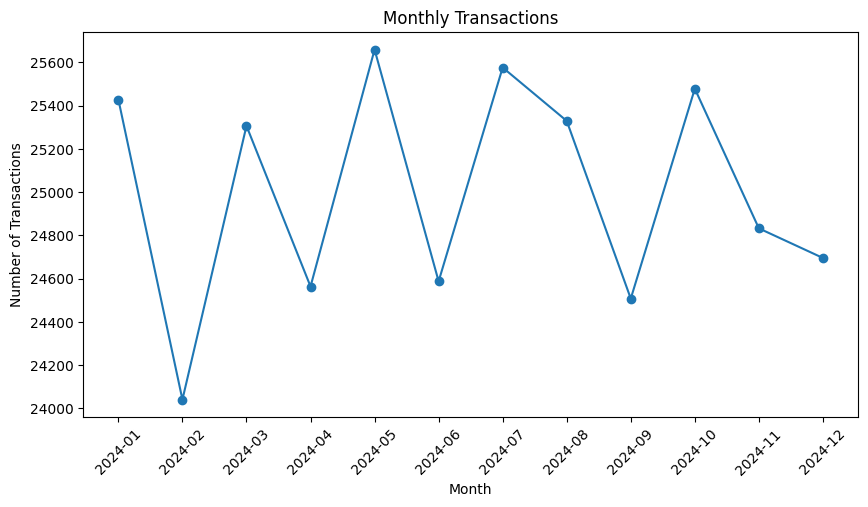

In [44]:
##4. Monthly Transaction Chart
plt.figure(figsize=(10,5))
plt.plot(monthly["Date"].astype(str), monthly["Transactions"], marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Transactions")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.show()


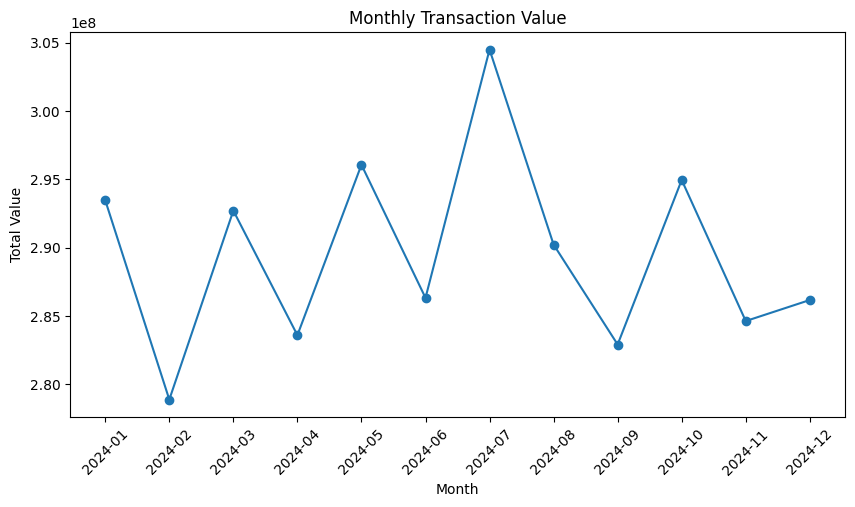

In [45]:
##5. Monthly Transaction Value
plt.figure(figsize=(10,5))
plt.plot(monthly["Date"].astype(str), monthly["Total_Value"], marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Transaction Value")
plt.xlabel("Month")
plt.ylabel("Total Value")
plt.show()






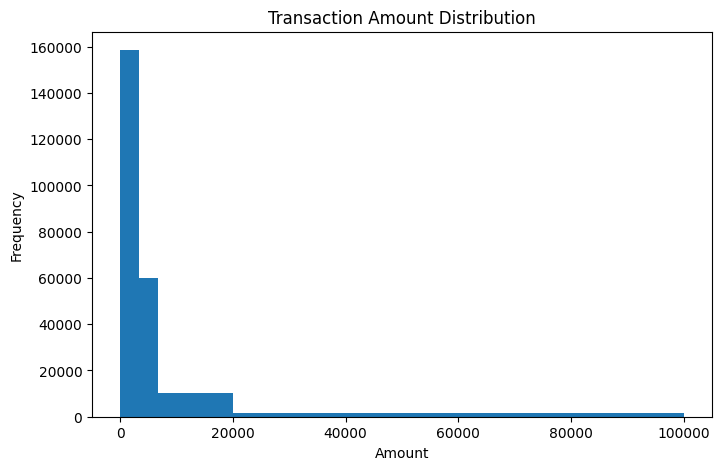

In [46]:
##6. Amount Distribution
plt.figure(figsize=(8,5))
plt.hist(transactions["Amount"], bins=30)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

In [47]:
##7. Top 10 Users by Transaction Value
top_users = transactions.groupby("User_ID").agg(
    Transactions=("Transaction_ID", "count"),
    Total_Value=("Amount", "sum")
).sort_values("Total_Value", ascending=False).head(10)

top_users

,Transactions,Total_Value
User_ID,,
PP0028780,6,349166.69
PP1075901,8,341614.07
PP0019432,6,340158.16
PP1073199,4,339374.81
PP0035403,8,338375.08
PP0048328,7,336189.81
PP1053341,5,332905.46
PP0024185,8,330492.35
PP1052317,6,328541.64


In [48]:
##8. Reason Analysis
reason_analysis = transactions.groupby("Reason").agg(
    Transactions=("Transaction_ID", "count"),
    Total_Value=("Amount", "sum")
).sort_values("Transactions", ascending=False)

reason_analysis

,Transactions,Total_Value
Reason,,
Successful,287993,3.333026e+09
Server error,4053,4.774685e+07
Wrong PIN,3315,1.323183e+07
Insufficient amount,3304,1.289339e+07
Wrong Info,700,3.520166e+07
Bank Denied,635,3.222211e+07


In [51]:
##9. Join Users + Transactions
df = transactions.merge(user, on="User_ID", how="left")

df.head()

,Transaction_ID,Amount,User_ID,Service,Service Type,Payment_Status,Reason,Date,Name,Age,Join_Date,Unnamed: 4,0
0,RCG_0C338474B366,926.59,PP0021371,Recharge_Bills,FASTag Recharge,Successful,Successful,2024-06-09,Katherine Howard,50,2023-08-28,NaN,NaN
1,RCG_6B3B86B07A76,1211.64,PP0002388,Recharge_Bills,DTH,Successful,Successful,2024-08-04,Kimberly Mueller,34,2024-08-10,NaN,NaN
2,RCG_767822392A0E,746.27,PP1101831,Recharge_Bills,Cable TV,Successful,Successful,2024-02-19,Scott Davis,36,2023-09-28,NaN,NaN
3,RCG_527E6AC74B11,1319.89,PP0033099,Recharge_Bills,Mobile Recharge,Successful,Successful,2024-12-22,Gina Williams,25,2023-10-09,NaN,NaN
4,RCG_6B50A8C694E1,112.44,PP1059869,Recharge_Bills,Cable TV,Successful,Successful,2024-09-07,Timothy Hernandez,58,2024-07-13,NaN,NaN


In [52]:
##10. Age Group Analysis
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 24, 34, 44, 54, 100],
    labels=["18-24", "25-34", "35-44", "45-54", "55+"]
)

age_analysis = df.groupby("Age_Group", observed=False).agg(
    Transactions=("Transaction_ID_x", "count"),
    Total_Value=("Amount_x", "sum")
)

age_analysis

,Transactions,Total_Value
Age_Group,,
18-24,48605,5.683061e+08
25-34,69051,7.940220e+08
35-44,70172,8.139488e+08
45-54,69872,8.082841e+08
55+,42300,4.897610e+08


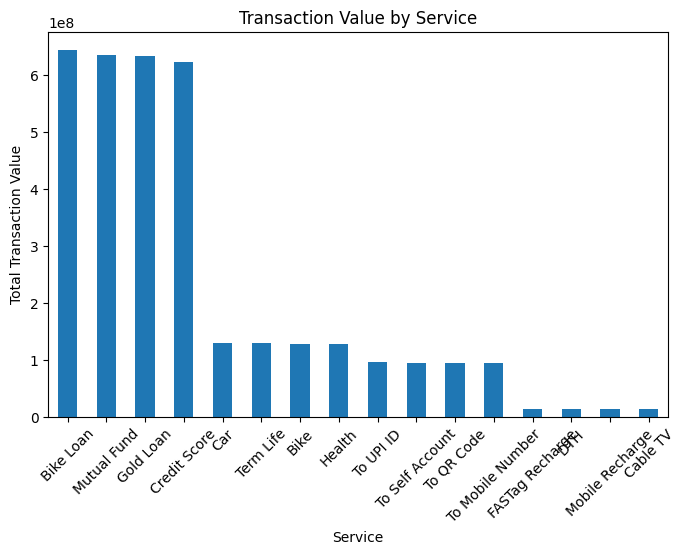

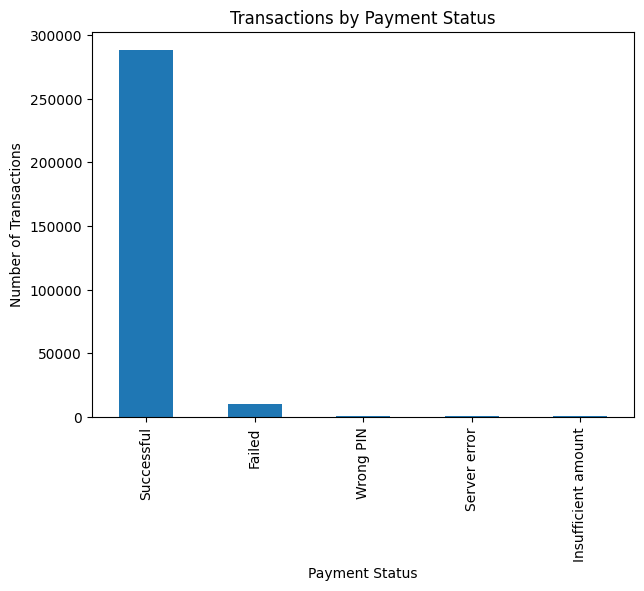

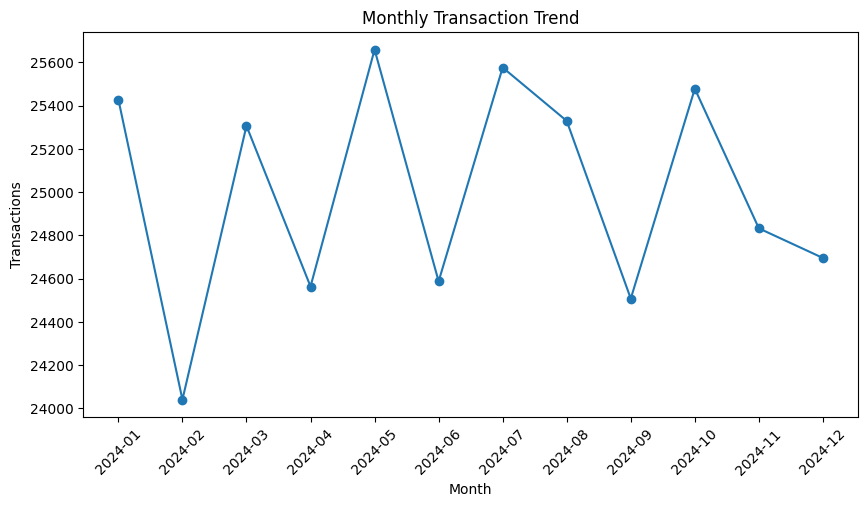

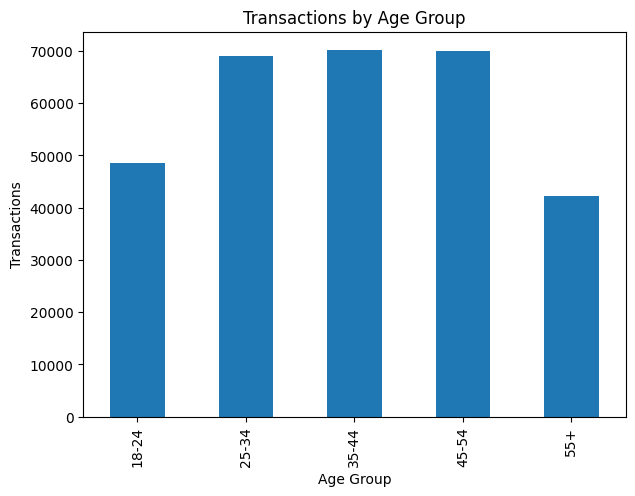

Total Transactions: 300000
Total Transaction Value: 3474321934.16
Average Transaction Value: 11581.07
Successful Transactions: 287993


In [53]:
##1 Service-wise Transaction Value
service_type["Total_Value"].plot(kind="bar", figsize=(8,5))
plt.title("Transaction Value by Service")
plt.xlabel("Service")
plt.ylabel("Total Transaction Value")
plt.xticks(rotation=45)
plt.show()
##2 Payment Status
status_analysis["Transactions"].plot(kind="bar", figsize=(7,5))
plt.title("Transactions by Payment Status")
plt.xlabel("Payment Status")
plt.ylabel("Number of Transactions")
plt.show()
##3 Monthly Transactions
plt.figure(figsize=(10,5))
plt.plot(monthly["Date"].astype(str), monthly["Transactions"], marker="o")
plt.title("Monthly Transaction Trend")
plt.xlabel("Month")
plt.ylabel("Transactions")
plt.xticks(rotation=45)
plt.show()
##4 Age Group
age_analysis["Transactions"].plot(kind="bar", figsize=(7,5))
plt.title("Transactions by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Transactions")
plt.show()

print("Total Transactions:", len(transactions))
print("Total Transaction Value:", round(transactions["Amount"].sum(), 2))
print("Average Transaction Value:", round(transactions["Amount"].mean(), 2))
print("Successful Transactions:",
      (transactions["Payment_Status"] == "Successful").sum())

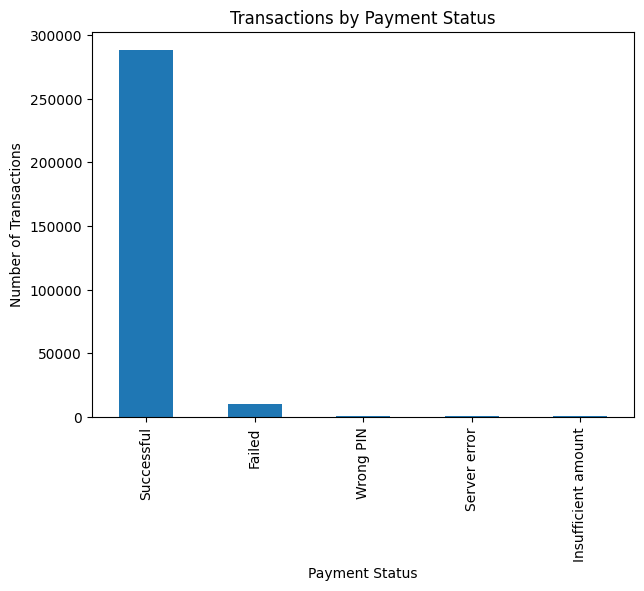

In [54]:
##2 Payment Status
status_analysis["Transactions"].plot(kind="bar", figsize=(7,5))
plt.title("Transactions by Payment Status")
plt.xlabel("Payment Status")
plt.ylabel("Number of Transactions")
plt.show()


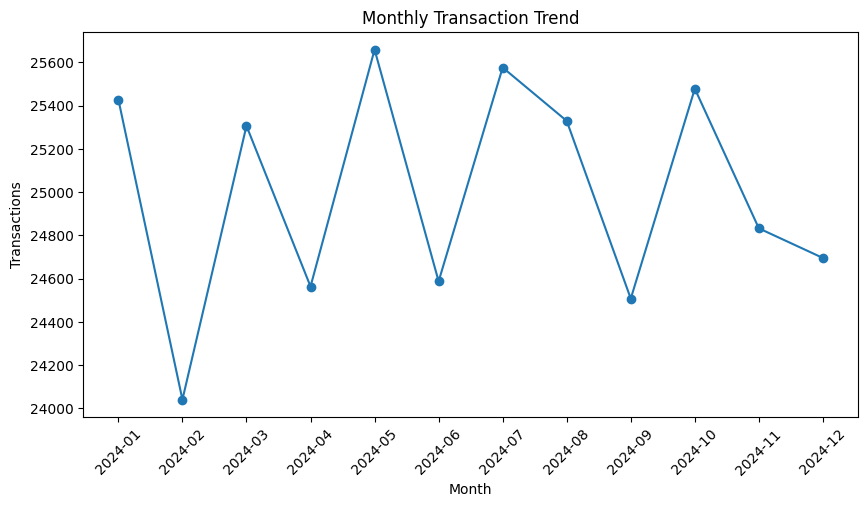

In [55]:
##3 Monthly Transactions
plt.figure(figsize=(10,5))
plt.plot(monthly["Date"].astype(str), monthly["Transactions"], marker="o")
plt.title("Monthly Transaction Trend")
plt.xlabel("Month")
plt.ylabel("Transactions")
plt.xticks(rotation=45)
plt.show()


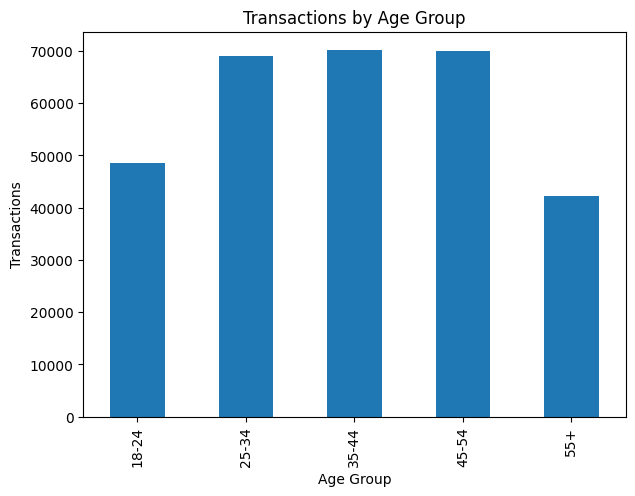

In [56]:
##4 Age Group
age_analysis["Transactions"].plot(kind="bar", figsize=(7,5))
plt.title("Transactions by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Transactions")
plt.show()



In [57]:
print("Total Transactions:", len(transactions))
print("Total Transaction Value:", round(transactions["Amount"].sum(), 2))
print("Average Transaction Value:", round(transactions["Amount"].mean(), 2))
print("Successful Transactions:",
      (transactions["Payment_Status"] == "Successful").sum())

Total Transactions: 300000
Total Transaction Value: 3474321934.16
Average Transaction Value: 11581.07
Successful Transactions: 287993
